<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Welcome to ZZSC9020

This Python notebook shows how to clone the course GitHub repository on Google Colab.

You can develop your data analysis on Google Colab without downloading the data to your computer.

In [42]:
# Import any packages
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import plot_tree
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV




In [17]:
# Joint forecastdemand_nsw files into a single file. 
!cat data/NSW/forecastdemand_nsw.csv.zip.part* > data/NSW/forecastdemand_nsw.csv.zip

# Unzip the data files into the data folder
!unzip -o data/NSW/forecastdemand_nsw.csv.zip -d data/NSW
!unzip -o data/NSW/temperature_nsw.csv.zip -d data/NSW
!unzip -o data/NSW/totaldemand_nsw.csv.zip -d data/NSW

# Remove forecastdemand_nsw.csv.zip
!rm data/NSW/forecastdemand_nsw.csv.zip

Archive:  data/NSW/forecastdemand_nsw.csv.zip
  inflating: data/NSW/forecastdemand_nsw.csv  
Archive:  data/NSW/temperature_nsw.csv.zip
  inflating: data/NSW/temperature_nsw.csv  
Archive:  data/NSW/totaldemand_nsw.csv.zip
  inflating: data/NSW/totaldemand_nsw.csv  


In [18]:
# the forecastdemand_nsw.csv file
df_forecast = pd.read_csv('data/NSW/forecastdemand_nsw.csv')

# the temperature_nsw.csv file
df_temperature = pd.read_csv('data/NSW/temperature_nsw.csv')

# inspect the totaldemand_nsw.csv file
df_totaldemand = pd.read_csv('data/NSW/totaldemand_nsw.csv')

# Convert 'DATETIME' columns to datetime format (auto-infer format)
df_forecast['DATETIME'] = pd.to_datetime(df_forecast['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
df_temperature['DATETIME'] = pd.to_datetime(df_temperature['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
df_totaldemand['DATETIME'] = pd.to_datetime(df_totaldemand['DATETIME'], format='mixed', dayfirst=True, errors='coerce')

# Group by 'DATETIME' and calculate the mean of the 'FORECASTDEMAND' column
df_forecast_avg = df_forecast.groupby('DATETIME')['FORECASTDEMAND'].mean().reset_index()

# Merge the first two DataFrames on 'DATETIME'
df_temp_forecast = pd.concat([df_forecast_avg, df_temperature], axis=1)

# Merge the above with the third DataFrame
df_merged = pd.concat([df_temp_forecast, df_totaldemand], axis=1)

# drop duplicate 'DATETIME' columns if any
df_merged = df_merged.loc[:,~df_merged.columns.duplicated()]
# drop unnecessary columns if any
df_merged = df_merged.drop(columns=['LOCATION', 'REGIONID'], errors='ignore')
print(df_merged.head())

             DATETIME  FORECASTDEMAND  TEMPERATURE  TOTALDEMAND
0 2010-01-01 00:00:00     7824.411831         23.1      8038.00
1 2010-01-01 00:30:00     7680.510417         23.1      7809.31
2 2010-01-01 01:00:00     7428.971370         22.9      7483.69
3 2010-01-01 01:30:00     7084.802162         22.7      7117.23
4 2010-01-01 02:00:00     6751.369600         22.6      6812.03


In [19]:
# Resample by day and calculate min, max, and mean for TEMPERATURE
df_daily = df_merged.set_index('DATETIME').resample('D').agg({
    'TEMPERATURE': ['min', 'max', 'mean'],
    'FORECASTDEMAND': 'mean',
    'TOTALDEMAND': 'mean'
}).reset_index().set_index('DATETIME')

print(df_daily.head())


           TEMPERATURE                  FORECASTDEMAND  TOTALDEMAND
                   min   max       mean           mean         mean
DATETIME                                                           
2010-01-01        22.1  28.8  25.112500    7723.688982  7801.352917
2010-01-02        22.4  29.4  25.052083    7804.668591  8017.459792
2010-01-03        18.3  22.9  19.868750    7491.520488  7399.899583
2010-01-04        17.9  22.9  19.627083    8592.014274  8241.720208
2010-01-05        15.4  27.3  21.529167    8907.999454  8827.813125


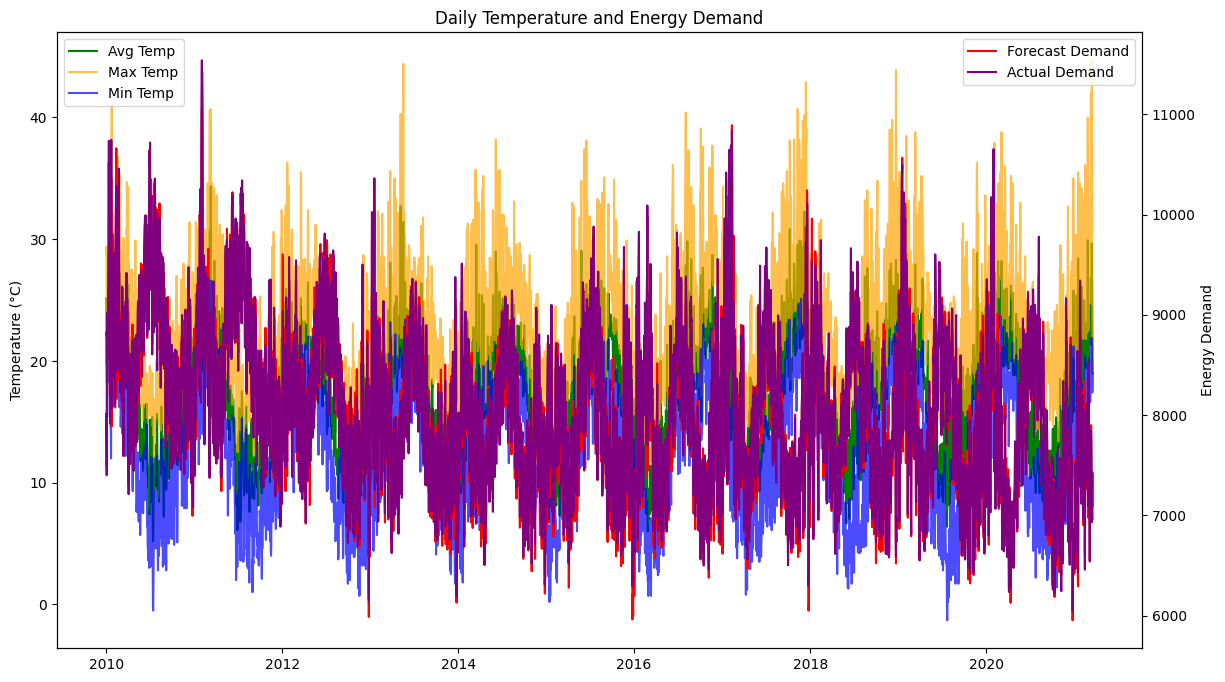

In [20]:
plt.figure(figsize=(14, 8))
ax1 = plt.gca()

# Plot temperature stats on left y-axis
ax1.plot(df_daily.index, df_daily['TEMPERATURE']['mean'], label='Avg Temp', color='green')
ax1.plot(df_daily.index, df_daily['TEMPERATURE']['max'], label='Max Temp', color='orange', alpha=0.7)
ax1.plot(df_daily.index, df_daily['TEMPERATURE']['min'], label='Min Temp', color='blue', alpha=0.7)
ax1.set_ylabel('Temperature (°C)')
ax1.legend(loc='upper left')

# Create right y-axis for demand
ax2 = ax1.twinx()
ax2.plot(df_daily.index, df_daily['FORECASTDEMAND']['mean'], label='Forecast Demand', color='red')
ax2.plot(df_daily.index, df_daily['TOTALDEMAND']['mean'], label='Actual Demand', color='purple')
ax2.set_ylabel('Energy Demand')
ax2.legend(loc='upper right')

plt.title('Daily Temperature and Energy Demand')
plt.xlabel('Date')
plt.show()

In [ ]:
# Create feature matrix X with multiple columns
X = pd.DataFrame({
    'temp_mean': df_daily['TEMPERATURE']['mean'],
    'temp_min': df_daily['TEMPERATURE']['min'],
    'temp_max': df_daily['TEMPERATURE']['max']
    })

# Target variable
y = df_daily['TOTALDEMAND']['mean'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor()
model.fit(X_train, y_train)

MSE: 800213.0104868733
R2: -0.2294469701379438


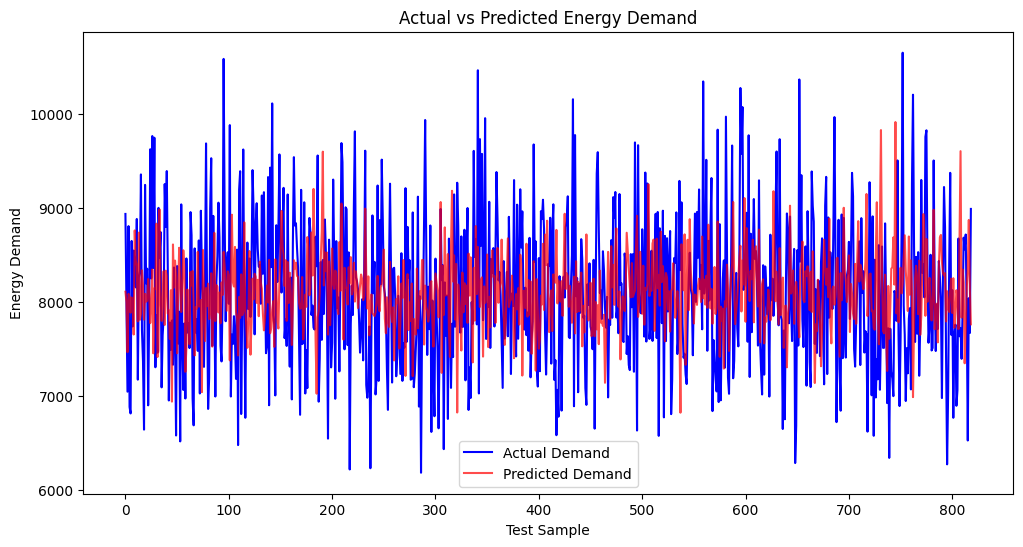

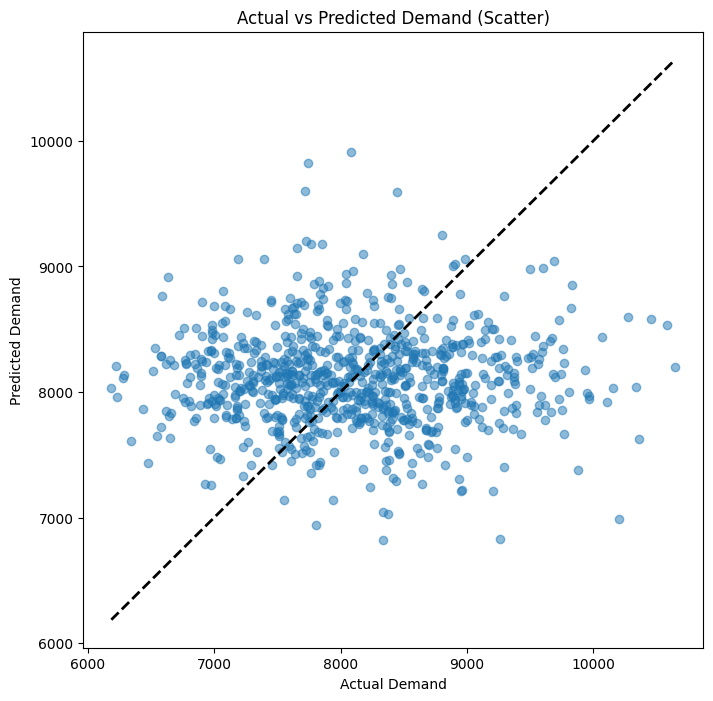

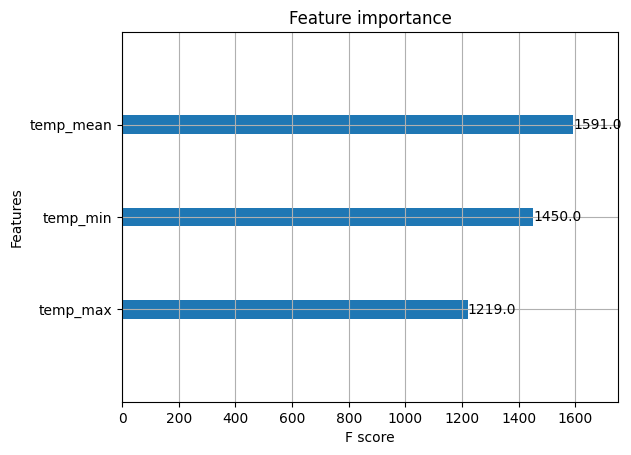

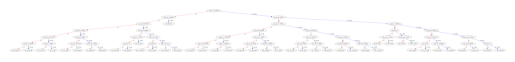

In [30]:
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Demand', color='blue')
plt.plot(y_pred, label='Predicted Demand', color='red', alpha=0.7)
plt.title('Actual vs Predicted Energy Demand')
plt.xlabel('Test Sample')
plt.ylabel('Energy Demand')
plt.legend()
plt.show()

# Scatter plot of actual vs predicted

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Demand (Scatter)')
plt.show()

# Feature importance plot
xgb.plot_importance(model)
# Tree plot with higher resolution
xgb.plot_tree(model, num_trees=0)
plt.savefig("xgboost-plots/xgboost_tree.png", dpi=1200, bbox_inches='tight')


## First Model Results

The initial model used only average, max, and min daily temperature to predict total energy demand.

**Performance:**
- **Mean Squared Error (MSE):** 800,213
- **R² Score:** -0.23

---

### Suggestions for Improvement

**Add More Features**
- Day of week, month, holidays (extract from `DATETIME`)
- Lagged demand/temperature values (previous days)

**Feature Engineering**
- Rolling averages (e.g., 3-day mean temperature)
- Temperature difference (max - min)
- Interaction terms (e.g., temp x humidity - need to add)

**Hyperparameter Tuning**
- Use `GridSearchCV` or `RandomizedSearchCV` to tune:
    - `n_estimators`
    - `max_depth`
    - `learning_rate`
    - `subsample`
    - `colsample_bytree`

**Data Cleaning**
- Remove or impute missing values
- Check for outliers

**Model Validation**
- Use cross-validation (`cross_val_score`)
- Try different train/test splits

**Try More Advanced Models**
- Ensemble with other regressors (RandomForest, LightGBM)
- Stack models

In [56]:
# Feature engineering: add day of week, month, and rolling averages
df_feat = df_merged.copy()
df_feat = df_feat.dropna(subset=['DATETIME', 'TEMPERATURE', 'TOTALDEMAND'])

df_feat['dayofweek'] = df_feat['DATETIME'].dt.dayofweek
df_feat['month'] = df_feat['DATETIME'].dt.month

# Rolling averages (3-day mean temperature)
df_feat['temp_rolling3'] = df_feat['TEMPERATURE'].rolling(window=3, min_periods=1).mean()
df_feat['temp_diff'] = df_feat['TEMPERATURE'] - df_feat['TEMPERATURE'].shift(1)
df_feat['extreme_hot'] = (df_feat['TEMPERATURE'] > 35).astype(int)
df_feat['extreme_cold'] = (df_feat['TEMPERATURE'] < 5).astype(int)

# One-hot encode day of week, month and extreme weather
df_feat = pd.get_dummies(df_feat, columns=['dayofweek', 'month', 'extreme_hot', 'extreme_cold'], drop_first=True)

# Feature matrix X and target y
feature_cols = ['TEMPERATURE', 'FORECASTDEMAND', 'temp_rolling3', 'temp_diff'] + \
               [col for col in df_feat.columns if col.startswith('dayofweek_') or col.startswith('month_')]
X = df_feat[feature_cols].fillna(0)
y = df_feat['TOTALDEMAND'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomizedSearchCV for XGBoost
xgb_model = xgb.XGBRegressor()
param_distributions = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [7, 10, 15, 20],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Params:", random_search.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=10, n_estimators=200, reg_alpha=1, reg_lambda=5, subsample=1.0; total time=   4.4s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=10, n_estimators=200, reg_alpha=1, reg_lambda=5, subsample=1.0; total time=   4.4s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.01, max_depth=10, n_estimators=200, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   5.1s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.01, max_depth=10, n_estimators=200, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   5.0s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.01, max_depth=10, n_estimators=200, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   5.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=10, n_estimators=200, reg_alpha=1, reg_lambda=5, subsample=1.0; total time=   4.6s
[CV] END

/Users/liammitrodobson/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.01, max_depth=15, n_estimators=200, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=  14.8s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.01, max_depth=15, n_estimators=200, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=  14.4s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.01, max_depth=15, n_estimators=200, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=  13.3s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_depth=15, n_estimators=200, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=  14.7s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_depth=15, n_estimators=200, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=  15.3s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_depth=15, n_estimators=200, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=  15.5s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.01, max_dept

MSE: 36859.91415559542
R2: 0.9783766108950757


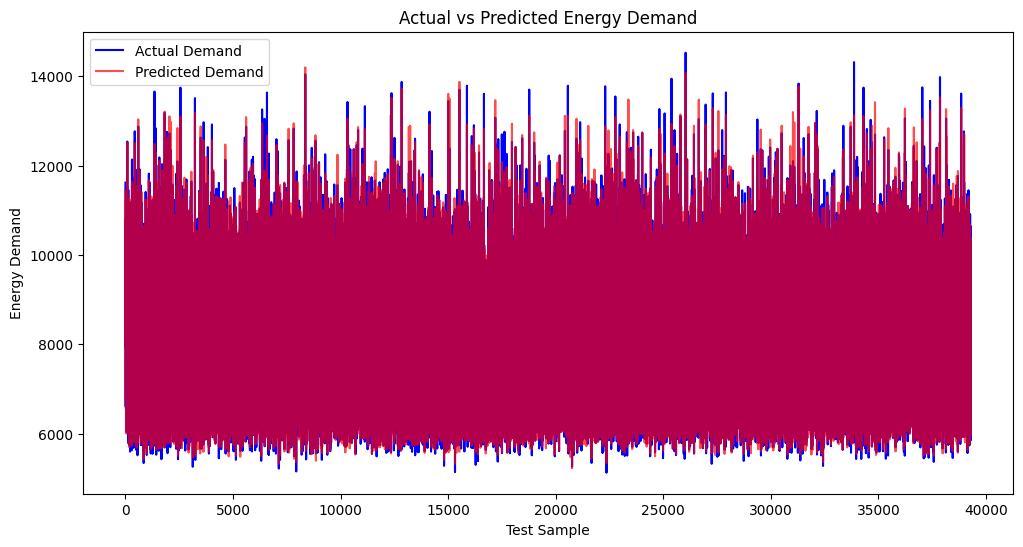

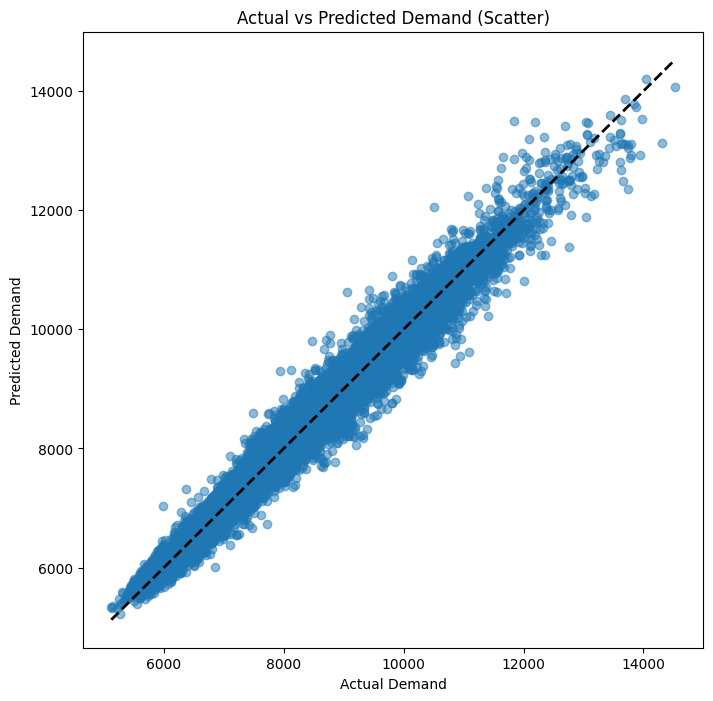

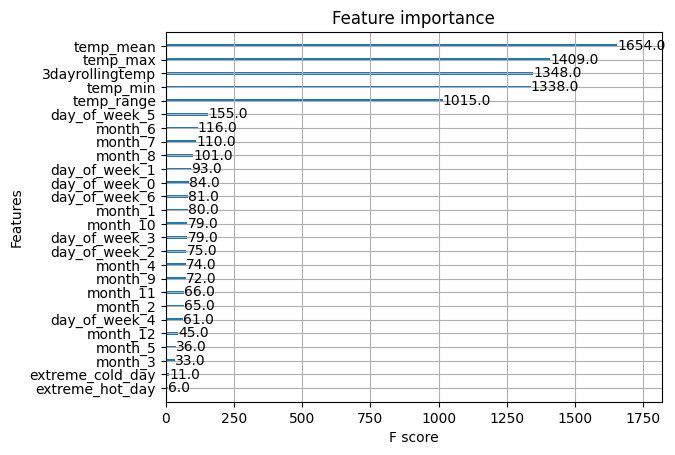

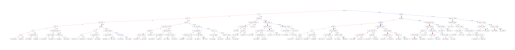

In [60]:
# Use X_test directly, as it matches the model's training features
y_pred = best_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Demand', color='blue')
plt.plot(y_pred, label='Predicted Demand', color='red', alpha=0.7)
plt.title('Actual vs Predicted Energy Demand')
plt.xlabel('Test Sample')
plt.ylabel('Energy Demand')
plt.legend()
plt.show()

# Scatter plot of actual vs predicted

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Demand (Scatter)')
plt.show()

# Feature importance plot
xgb.plot_importance(model)
# Tree plot with higher resolution
xgb.plot_tree(model, num_trees=0)
plt.savefig("xgboost-plots/xgboost_tree.png", dpi=1200, bbox_inches='tight')


In [32]:
# Lastly delete the unzipped files to save space
!rm data/NSW/forecastdemand_nsw.csv
!rm data/NSW/temperature_nsw.csv
!rm data/NSW/totaldemand_nsw.csv

rm: data/NSW/forecastdemand_nsw.csv: No such file or directory
rm: data/NSW/temperature_nsw.csv: No such file or directory
rm: data/NSW/totaldemand_nsw.csv: No such file or directory
